<a href="https://colab.research.google.com/github/kiaraspreckley/KiaraSpreckley_DataScience_GenAI_Submission/blob/main/Machine_Learning_Full_Practice_Test_Loan_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I need to start by loading the data. I am going to use Genai with the query

"please create a data frame from “loan_data.csv”"



In [ ]:
import pandas as pd


df = pd.read_csv("loan_data.csv")
df.head()


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,17.2,25579,692,5.3,895,10820,0,0,0,600,17.02,0.423,0.023,0.008,1
1,33,7.3,43087,627,3.5,169,16550,0,1,0,53300,14.10,0.384,1.237,0.412,0
2,42,1.1,20840,689,8.4,17,7852,0,0,0,2100,18.33,0.377,0.101,0.034,1
3,53,0.5,29147,692,9.8,1480,11603,0,1,0,2900,18.74,0.398,0.099,0.033,1
4,32,12.5,63657,630,7.2,209,12424,0,0,0,99600,13.92,0.195,1.565,0.522,1


The data frame looks like it has worked. I will firstly check for any missing values, I will copy this code from "5_02_Modelling_Hackathon.ipynb"

In [ ]:
df.isnull().sum()


,0
age,0
years_employed,0
annual_income,0
credit_score,0
credit_history_years,0
savings_assets,0
current_debt,0
defaults_on_file,0
delinquencies_last_2yrs,0
derogatory_marks,0


Okay great! There are no outliers! All data is numeric and there are no missing values, if this was not the case, I would need to handle the missing data and potentially drop some rows/columns, if there was categorical text data, I would need to encode these to numeric.


I will now start with the first step of seperating the x and the y variables. The y variable will be the category "loan status".

I will use the AI prompt "seperate the Y, loan stautus, and display the new X and Y dataframe"


In [ ]:
print("X DataFrame head:")
display(X.head())

print("y Series head:")
display(y.head())

X DataFrame head:


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio
0,40,17.2,25579,692,5.3,895,10820,0,0,0,600,17.02,0.423,0.023,0.008
1,33,7.3,43087,627,3.5,169,16550,0,1,0,53300,14.10,0.384,1.237,0.412
2,42,1.1,20840,689,8.4,17,7852,0,0,0,2100,18.33,0.377,0.101,0.034
3,53,0.5,29147,692,9.8,1480,11603,0,1,0,2900,18.74,0.398,0.099,0.033
4,32,12.5,63657,630,7.2,209,12424,0,0,0,99600,13.92,0.195,1.565,0.522


y Series head:


,loan_status
0,1
1,0
2,1
3,1
4,1


I now have the x data set and a seperate set for the y variable.

Now, I will apply Min-Max scaling to the features. This is important for normalization, ensuring all features contribute equally to the model's function without larger magnitudes dominating.

I will use the AI prompt "Scale the X variables using MinMax scaler"

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("X_scaled DataFrame head:")
display(X_scaled.head())

X_scaled DataFrame head:


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio
0,0.423077,0.431078,0.045017,0.685259,0.176667,0.002983,0.065897,0.0,0.000000,0.0,0.001005,0.648235,0.527569,0.007526,0.007530
1,0.288462,0.182957,0.119519,0.555777,0.116667,0.000563,0.100990,0.0,0.111111,0.0,0.530653,0.476471,0.478697,0.616658,0.615964
2,0.461538,0.027569,0.024851,0.679283,0.280000,0.000057,0.047721,0.0,0.000000,0.0,0.016080,0.725294,0.469925,0.046663,0.046687
3,0.673077,0.012531,0.060200,0.685259,0.326667,0.004933,0.070693,0.0,0.111111,0.0,0.024121,0.749412,0.496241,0.045660,0.045181
4,0.269231,0.313283,0.207051,0.561753,0.240000,0.000697,0.075721,0.0,0.000000,0.0,0.995980,0.465882,0.241855,0.781234,0.781627


The 'x' variables appear to have been scaled accuratley, all variables are now on a scale of 0-1.

 I will now do the train-test split , I will use the AI prompt " Split X and y into X_train, X_test, y_train, y_test"

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 15)
X_test shape: (10000, 15)
y_train shape: (40000,)
y_test shape: (10000,)


The Y is now seperated and the X values are normalised

We have the following datasets:

X_train: 40,000 rows, 15 columns

X_test: 10,000 rows, 15 columns

y_train: 40,000 rows, 1 column (target variable)

y_test: 10,000 rows, 1 column (target variable)

I used the AI prompt "detail the size of the different data sets" to get this information

With the data now preprocessed and scaled, I will begin building machine learning models. I Will start with a decison tree because decision trees are simpler, non-linear models that can be good for understanding feature importance.

I will copy the code from the GitHub "4_01_Decision_Trees.ipynb"

In [ ]:
from sklearn.tree import DecisionTreeClassifier as DTC

# create the model
DTC_algo = DTC()
DTC_algo

DecisionTreeClassifier()

In [ ]:
DTC_model = DTC_algo.fit(X_train, y_train)
DTC_model


DecisionTreeClassifier()

I will use the AI prompt: "for the decision tree, calculate accuracy, macro precision, recall, f1-score."

I will use accuracy as a measure to compare, to see for every prediction, what percentage were correct. This is based on the test data.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score

y_pred = DTC_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {precision_macro:.4f}")

Accuracy: 0.8365
Macro Precision: 0.8349
Macro Recall: 0.8350
Macro F1-score: 0.8349


Our decision Tree Model seems to be off to a good start! The Accuracy is about 83.65%, which is pretty solid. Given that the Macro Precision, Recall, and F1-score are all hovering right around that same mark (about 0.835). This tells us the model isn't cheating by just predicting the most common outcome everytime, it's actually doing a decent job identifying both the good loans and the bad ones.

I will create a decison tree to visualise this, and see if it is overfitting. I will copy the code from the GitHub "4_01_Decision_Trees.ipynb"

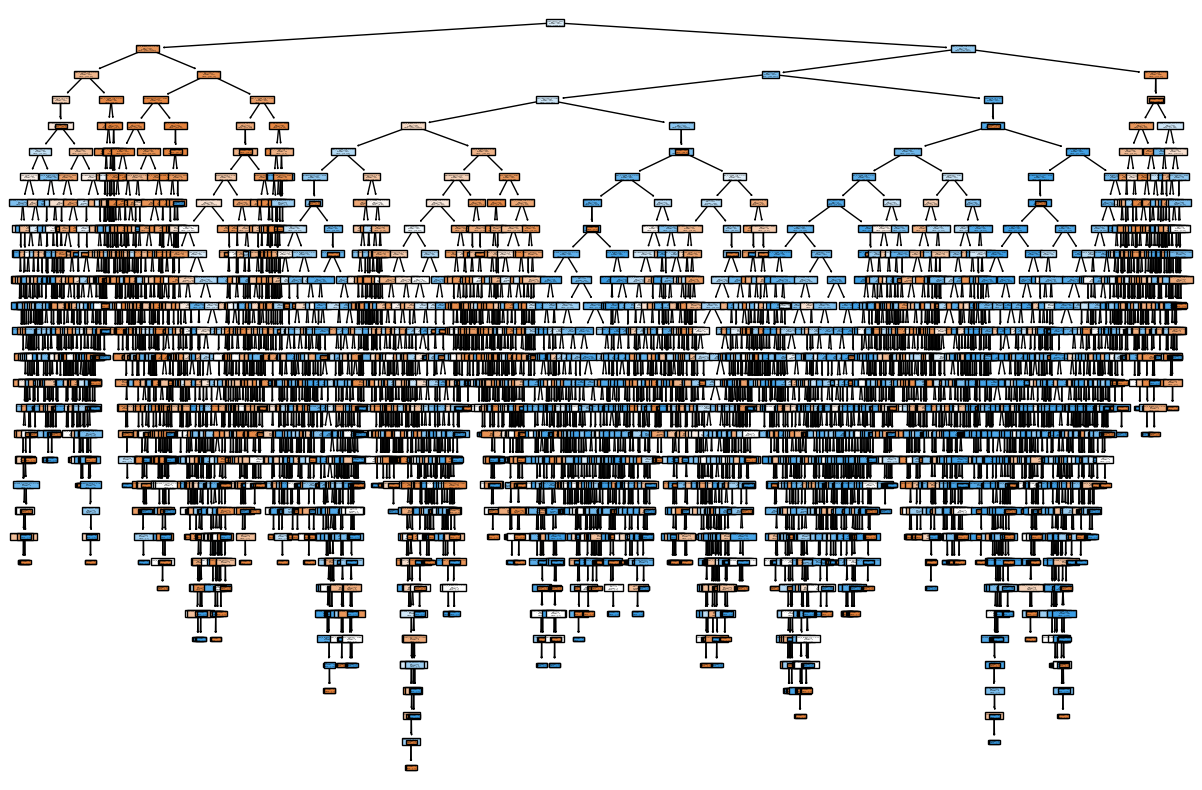

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(DTC_model, filled=True, feature_names=X_train.columns)
plt.show()

I can tell that this tree appears to have over fit. Regularisation may help, I will search to apply some hyperperameters.

I will also create a confusion matrix so I can compare the matrix before and after adding hyperperameters. I will use the AI prompt "create a confusion matrix based on this initial decision tree"


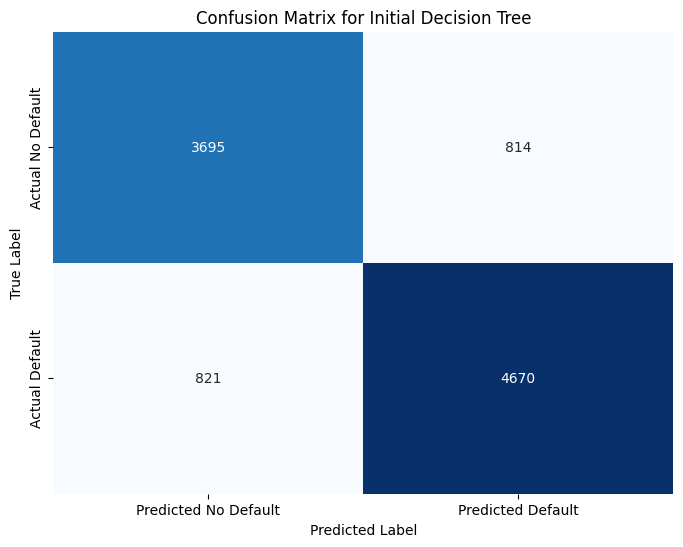

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = DTC_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted No Default', 'Predicted Default'],
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Confusion Matrix for Initial Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

I will use the AI prompt: I will use the AI prompt: "add a hyperperameter to the decision tree for max depth and min samples split"

In [ ]:
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'max_depth': randint(3, 9),  # Draw from a uniform distribution between 3 and 8 (exclusive of 9)
    'min_samples_split': randint(3, 9) # Draw from a uniform distribution between 3 and 8
}

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled
# cv: Number of folds in cross-validation
random_search = RandomizedSearchCV(dtc, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("RandomizedSearchCV completed.")
print(f"Best hyperparameters found: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")

RandomizedSearchCV completed.
Best hyperparameters found: {'max_depth': 8, 'min_samples_split': 7}
Best score: 0.8634000000000001


OR, I will search our hyperparameters and see what would be best, I have coppied this code from the GitHub "4_01_Decision_Trees.ipynb"



In [ ]:

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# this is the list of parameters we will tune. Some are fixed values some are distributions
tuned_parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(3, 9),  # Draw from a uniform distribution between 3 and 15
    'min_samples_split': randint(3, 9),  # Draw from a uniform distribution between 2 and 10
    'max_features': ['sqrt', 'log2', None]
}

# we will tune against f1_macro (to find the best choice)
score = 'f1_macro' # arbitrary choice

print(f"Tuning hyperparameters for {score}")
print("\n")

# do the search using 5 folds/chunks
clf = RandomizedSearchCV(DTC(), tuned_parameters, cv=5, random_state=1984,
                         scoring= score, n_iter=20, refit=True)

# pass the data to fit/train
clf.fit(X_train, y_train)

print("Best parameters set found on the training set:")
print(clf.best_params_)

Tuning hyperparameters for f1_macro


Best parameters set found on the training set:
{'criterion': 'entropy', 'max_depth': 8, 'max_features': None, 'min_samples_split': 7}


The AI has identifies the best max depth to be 8 and the best minimum samples split to be 7. I will now visualse how the decision tree looks to see if it is smaller and less prone to overfitting.

I will now visualise the new decision tree based on the dest decision tree classifer found from the randomised search.

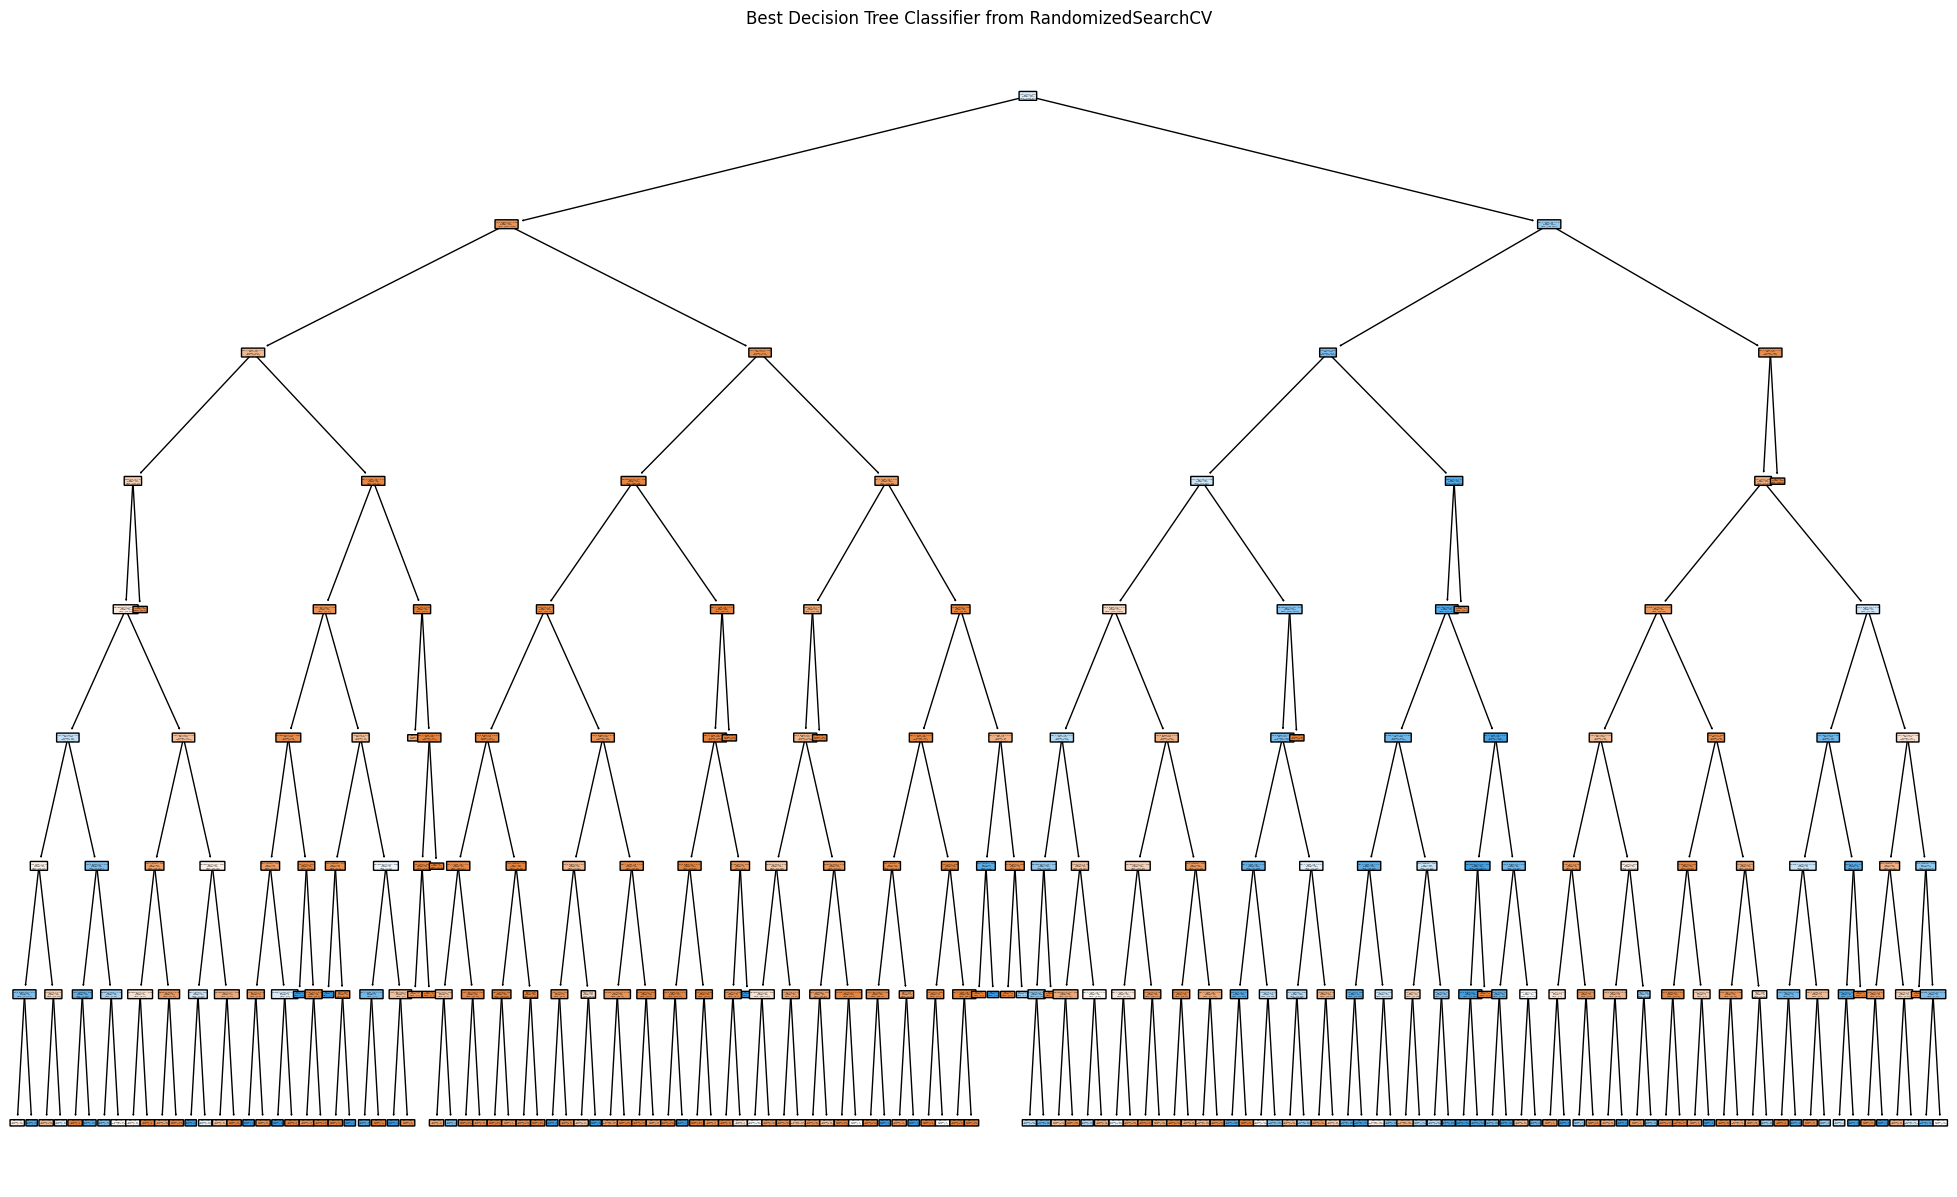

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get the best Decision Tree Classifier from RandomizedSearchCV
best_dtc_model = random_search.best_estimator_

plt.figure(figsize=(25, 15)) # Adjust figure size for better readability
plot_tree(best_dtc_model, filled=True, feature_names=X_train.columns, class_names=['Not Default', 'Default'], rounded=True)
plt.title("Best Decision Tree Classifier from RandomizedSearchCV");
plt.show()

The decision tree is now significantly smaller than before, however it does still apear to be bigger than the ideal. Given the data in this data set, it may not be as viable to make a smaller decision tree. A depth of 8 is fairly viable, however this tree is still quite wide, most likley due to the data. To test if this decision try has a better accuracy than before, I will now check the accuracy of this model with the new hyperperameters.

I have copied this code from the GitHub "4_01_Decision_Trees.ipynb". I have edited the text in the code to be in line with the test within my previous code.

I will then use the AI prompt "on the tuned decision tree calculate accuracy, macro precision, recall, f1-score"


In [ ]:
DTC_algo = DTC(**random_search.best_params_) # get the best parameters from randomized search
DTC_model = DTC_algo.fit(X_train, y_train)

In [ ]:
# predict the test data
predict = DTC_model.predict(X_test)

# seperate the first five predictions and the first five real values in y_test
for i in range(5):
  print(f'Predicted: {round(predict[i],2)}')
  print(f'Real: {y_test.iloc[i]}')
  print("\n")

print("\n")

print(f'Accuracy: {round(accuracy_score(y_test, predict),2)}')

Predicted: 1
Real: 1


Predicted: 1
Real: 1


Predicted: 0
Real: 0


Predicted: 0
Real: 0


Predicted: 1
Real: 1




Accuracy (Tuned Model): 0.8702
Macro Precision (Tuned Model): 0.8715
Macro Recall (Tuned Model): 0.8662
Macro F1-score (Tuned Model): 0.8681


with the new hyperperameters added, the accuracy has increased by approximatley 3% and so has the F1 score. This indicates that the original, untuned tree was indeed overfitting the training data, and the tuning process created a simpler, more generalized model that performs much better on unseen test data.

The final Macro F1-score of 0.8681 confirms the model achieves a strong and balanced capability in both Recall and Precision.

I will use the AI prompt "Create a new decision matrix on the tuned data"

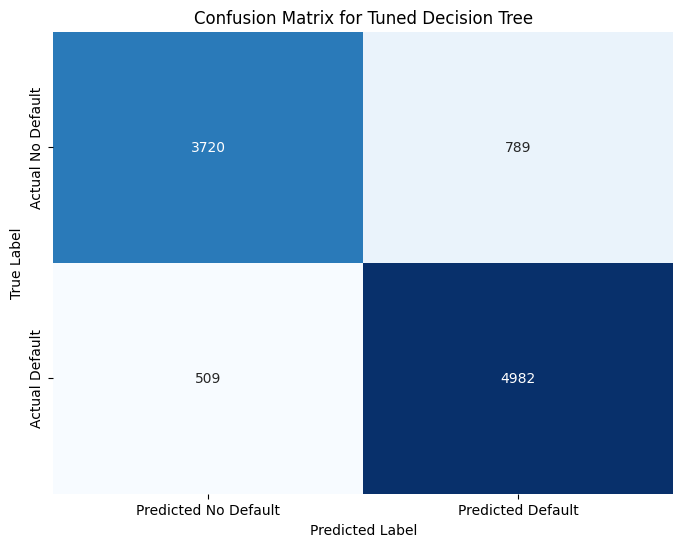

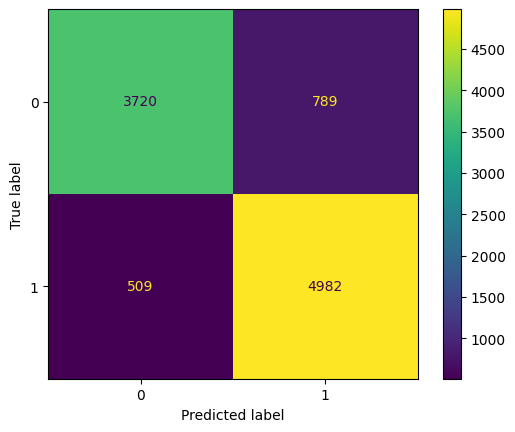

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as CM

# create a confusion matrix
CM.from_predictions(y_test, predict)

By comparison, with the tuned data, there is significantly less false negatives, and slightly less false positives.  The ideal balance may depend on the type of data and its implications.




I will now test the performance of random forest, GBDT, Logistic regression and XGBT to compare, i have copied the code from the GitHub "/5_01_Random_Forest_and_GBDT.ipynb"

I will start by running the macro precision, macro recall and macro F1 score on the training data.


In [ ]:
from sklearn.linear_model import LogisticRegression as LogR
from sklearn.ensemble import RandomForestClassifier as RF
from sklearn.ensemble import GradientBoostingClassifier as GBDT
from xgboost import XGBClassifier as XGB
from sklearn.metrics import precision_recall_fscore_support

LogR_algo = LogR()
LogR_model = LogR_algo.fit(X_train, y_train)

RF_algo = RF()
RF_model = RF_algo.fit(X_train, y_train)

GBDT_algo = GBDT()
GBDT_model = GBDT_algo.fit(X_train, y_train)

XGB_algo = XGB()
XGB_model = XGB_algo.fit(X_train, y_train)

models = [LogR_model, RF_model, GBDT_model, XGB_model]
names = ['Logistic Regression', 'Random Forest', 'GBDT', 'XGBDT']

for i in range(4):
  print(f"Model: {names[i]}")

  # predict based on training data
  predict = models[i].predict(X_train)

  # Calculate precision, recall, and F1-score
  precision, recall, f1_score, _ = precision_recall_fscore_support(y_train, predict, average='macro')
  print(f"Macro Precision: {precision}")
  print(f"Macro Recall: {recall}")
  print(f"Macro F1-score: {f1_score}")
  print("\n")

Model: Logistic Regression
Macro Precision: 0.8373367262104723
Macro Recall: 0.8343686807693627
Macro F1-score: 0.8355660218246259


Model: Random Forest
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1-score: 1.0


Model: GBDT
Macro Precision: 0.8926150739012277
Macro Recall: 0.8892534116974516
Macro F1-score: 0.890642262178831


Model: XGBDT
Macro Precision: 0.9372780138028503
Macro Recall: 0.9351814870105557
Macro F1-score: 0.9361211983062387




The random forest appears to score perfectly. I will compare it to the Test

I will use the AI prompt "predict on X_test and y_test, calculate accuracy, macro precision, recall, f1-score."

Model: Logistic Regression
Macro Precision (Test): 0.8412
Macro Recall (Test): 0.8388
Macro F1-score (Test): 0.8398


Model: Random Forest
Macro Precision (Test): 0.8854
Macro Recall (Test): 0.8838
Macro F1-score (Test): 0.8846


Model: GBDT
Macro Precision (Test): 0.8924
Macro Recall (Test): 0.8888
Macro F1-score (Test): 0.8903


Model: XGBDT
Macro Precision (Test): 0.8917
Macro Recall (Test): 0.8893
Macro F1-score (Test): 0.8903




Comparing the model performance between the training and unseen test datasets, the GBDT and Logistic Regression models shows the most similar results across both sets, with their Macro Precision metrics being consistently around 89% and 84% retrospectivley. This consistency suggests that these models, are less prone to overfitting

The initial observation that Random Forest achieved a perfect score on the training data strongly suggests that these models are overfitting. While they memorized the training examples flawlessly, their true performance on unseen data is lower, indicating they are not generalizing perfectly.



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# we get a load of warnings running the code so will supress them
import warnings
warnings.filterwarnings("ignore")

# create a hyperparameter search function for re-usability
def random_search(algo, hyperparameters, X_train, y_train):
  # do the search using 5 folds/chunks
  clf = RandomizedSearchCV(algo, hyperparameters, cv=5, random_state=2015,
                          scoring='precision_macro', n_iter=20, refit=True)

  # pass the data to fit/train
  clf.fit(X_train, y_train)

  return clf.best_params_



# Random Forest
RF_tuned_parameters = {
    'n_estimators': randint(50, 500), # Draw from a uniform distribution between 50 and 500
    'max_depth': randint(2, 7),  # Draw from a uniform distribution between 2 and 7
    'min_samples_split': randint(2, 7),  # Draw from a uniform distribution between 2 and 7
    'max_features': ['sqrt', 'log2', None]
}

RF_best_params = random_search(RF_algo, RF_tuned_parameters, X_train, y_train)


# Train the models

RF_algo = RF(**RF_best_params)
RF_model = RF_algo.fit(X_train, y_train)


# score the models
models = [RF_model] # redo this or it uses the old models

for i in range(len(models)): # for every model in the models list
  print(f"Model: {names[i]}")

  # predict based on training data
  predict = models[i].predict(X_train)

  # Calculate precision, recall, and F1-score
  precision, recall, f1_score, _ = precision_recall_fscore_support(y_train, predict, average='macro')
  print(f"Macro Precision: {precision}")
  print(f"Macro Recall: {recall}")
  print(f"Macro F1-score: {f1_score}")
  print("\n")


KeyboardInterrupt: 

In [ ]:
# Modified hyperparameter search function for re-usability
def random_search(algo, hyperparameters, X_train, y_train):
  # Reduced cv from 5 to 3
  # Reduced n_iter from 20 to 10
  clf = RandomizedSearchCV(algo, hyperparameters, cv=3, random_state=2015,
                          scoring='precision_macro', n_iter=10, refit=True)

  # pass the data to fit/train
  clf.fit(X_train, y_train)

  return clf.best_params_

# Random Forest
RF_tuned_parameters = {
    # Reduced upper bound from 500 to 200
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 7),
    'min_samples_split': randint(2, 7),
    'max_features': ['sqrt', 'log2', None]
}

# The number of models trained is now 10 (n_iter) * 3 (cv) = 30 models
# (down from 20 * 5 = 100 models) and each model trains faster due to lower n_estimators.

# Example of updated function call
RF_best_params = random_search(RF_algo, RF_tuned_parameters, X_train, y_train)

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# we get a load of warnings running the code so will supress them
import warnings
warnings.filterwarnings("ignore")

# create a hyperparameter search function for re-usability
def random_search(algo, hyperparameters, X_train, y_train):
  # do the search using 5 folds/chunks
  clf = RandomizedSearchCV(algo, hyperparameters, cv=5, random_state=2015,
                          scoring='precision_macro', n_iter=20, refit=True)

  # pass the data to fit/train
  clf.fit(X_train, y_train)

  return clf.best_params_


# Random Forest
RF_tuned_parameters = {
    'n_estimators': randint(50, 500), # Draw from a uniform distribution between 50 and 500
    'max_depth': randint(2, 7),  # Draw from a uniform distribution between 2 and 7
    'min_samples_split': randint(2, 7),  # Draw from a uniform distribution between 2 and 7
    'max_features': ['sqrt', 'log2', None]
}

RF_best_params = random_search(RF_algo, RF_tuned_parameters, X_train, y_train)

# Train the models

RF_algo = RF(**RF_best_params)
RF_model = RF_algo.fit(X_train, y_train)

# score the models
models = [RF_model] # redo this or it uses the old models

for i in range(len(models)): # for every model in the models list
  print(f"Model: {'Random forest'}")

  # predict based on training data
  predict = models[i].predict(X_train)

  # Calculate precision, recall, and F1-score
  precision, recall, f1_score, _ = precision_recall_fscore_support(y_train, predict, average='macro')
  print(f"Macro Precision: {precision}")
  print(f"Macro Recall: {recall}")
  print(f"Macro F1-score: {f1_score}")
  print("\n")

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint


# we get a load of warnings running the code so will supress them
import warnings
warnings.filterwarnings("ignore")


# create a hyperparameter search function for re-usability
def random_search(algo, hyperparameters, X_train, y_train):
 # do the search using 5 folds/chunks
 clf = RandomizedSearchCV(algo, hyperparameters, cv=5, random_state=2015,
                         scoring='precision_macro', n_iter=20, refit=True)


 # pass the data to fit/train
 clf.fit(X_train, y_train)


 return clf.best_params_






# Random Forest
RF_tuned_parameters = {

   'max_depth': randint(2, 7),  # Draw from a uniform distribution between 2 and 7
   'min_samples_split': randint(2, 7),  # Draw from a uniform distribution between 2 and 7

}


RF_best_params = random_search(RF_algo, RF_tuned_parameters, X_train, y_train)




# Train the models


RF_algo = RF(**RF_best_params)
RF_model = RF_algo.fit(X_train, y_train)




# score the models
models = [RF_model] # redo this or it uses the old models


for i in range(len(models)): # for every model in the models list
 print(f"Model: {names[i]}")


 # predict based on training data
 predict = models[i].predict(X_train)


 # Calculate precision, recall, and F1-score
 precision, recall, f1_score, _ = precision_recall_fscore_support(y_train, predict, average='macro')
 print(f"Macro Precision: {precision}")
 print(f"Macro Recall: {recall}")
 print(f"Macro F1-score: {f1_score}")
 print("\n")

KeyboardInterrupt: 

I created a hyperperameter for the random forest by itself because all other codes were taking too long to run when trying to do it together, I ideally would hyperperapeter on all of the different models, then compare the hyperperametered results of macro presions and F1 score on the training data to the test data, those which would have performed the best I would then decide 2 and use the confusion matrix to look into their errors and the differences between the two a lot closer.

Instead, I will compare the confusion matrix for GBTD and Logistic regression, as these two models appear to have the least overfitting when comparing the test and traning data.


logistic regression matrix


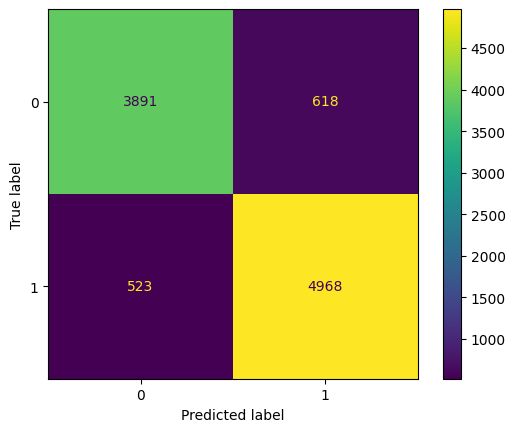

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay as CM

# Logistic Regression
print("logistic regression matrix")
predict = RF_model.predict(X_test)
CM.from_predictions(y_test, predict)

GBDT Confusion Matrix


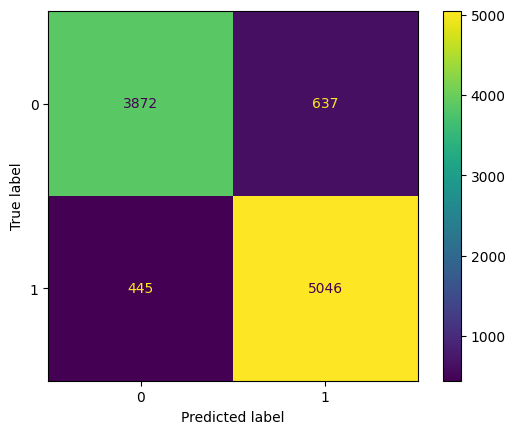

In [ ]:

# GBDT
print("GBDT Confusion Matrix")
predict = GBDT_model.predict(X_test)
print(CM.from_predictions(y_test, predict))

The GBDT has a lower number of flase negatives, however it has more false positives.

The false nagatives, these are bad loans that were incorrectly approved.
False Positives These are good loans that were incorrectly rejected.

Therefore, accepting slightly more False Positives (missed opportunities) with the GBDT to drastically reduce the high-cost False Negatives (actual losses) is the most risk-averse and financially responsible strategy for a lender.
